Mounted at /content/drive
✅ Libraries loaded
   LightGBM version : 4.6.0
✅ Config loaded
   Datasets         : 11
   Train/Test       : 70% / 30%
   n_estimators     : 100
   num_leaves       : 31
   learning_rate    : 0.1
   scale_pos_weight : 1.5
  LightGBM — num_leaves Sensitivity Analysis

  AAC        → nl=15:0.834  nl=31:0.839  nl=63:0.842  nl=127:0.842
             Best num_leaves = 63  (AUC=0.8421)

  DPC        → nl=15:0.789  nl=31:0.800  nl=63:0.796  nl=127:0.796
             Best num_leaves = 31  (AUC=0.8000)

  CTDC       → nl=15:0.823  nl=31:0.826  nl=63:0.817  nl=127:0.815
             Best num_leaves = 31  (AUC=0.8262)

  CTDT       → nl=15:0.824  nl=31:0.830  nl=63:0.820  nl=127:0.820
             Best num_leaves = 31  (AUC=0.8304)

  GAAC       → nl=15:0.803  nl=31:0.790  nl=63:0.785  nl=127:0.785
             Best num_leaves = 15  (AUC=0.8029)

  PAAC       → nl=15:0.791  nl=31:0.804  nl=63:0.791  nl=127:0.794
             Best num_leaves = 31  (AUC=0.8036)

  ProtBER

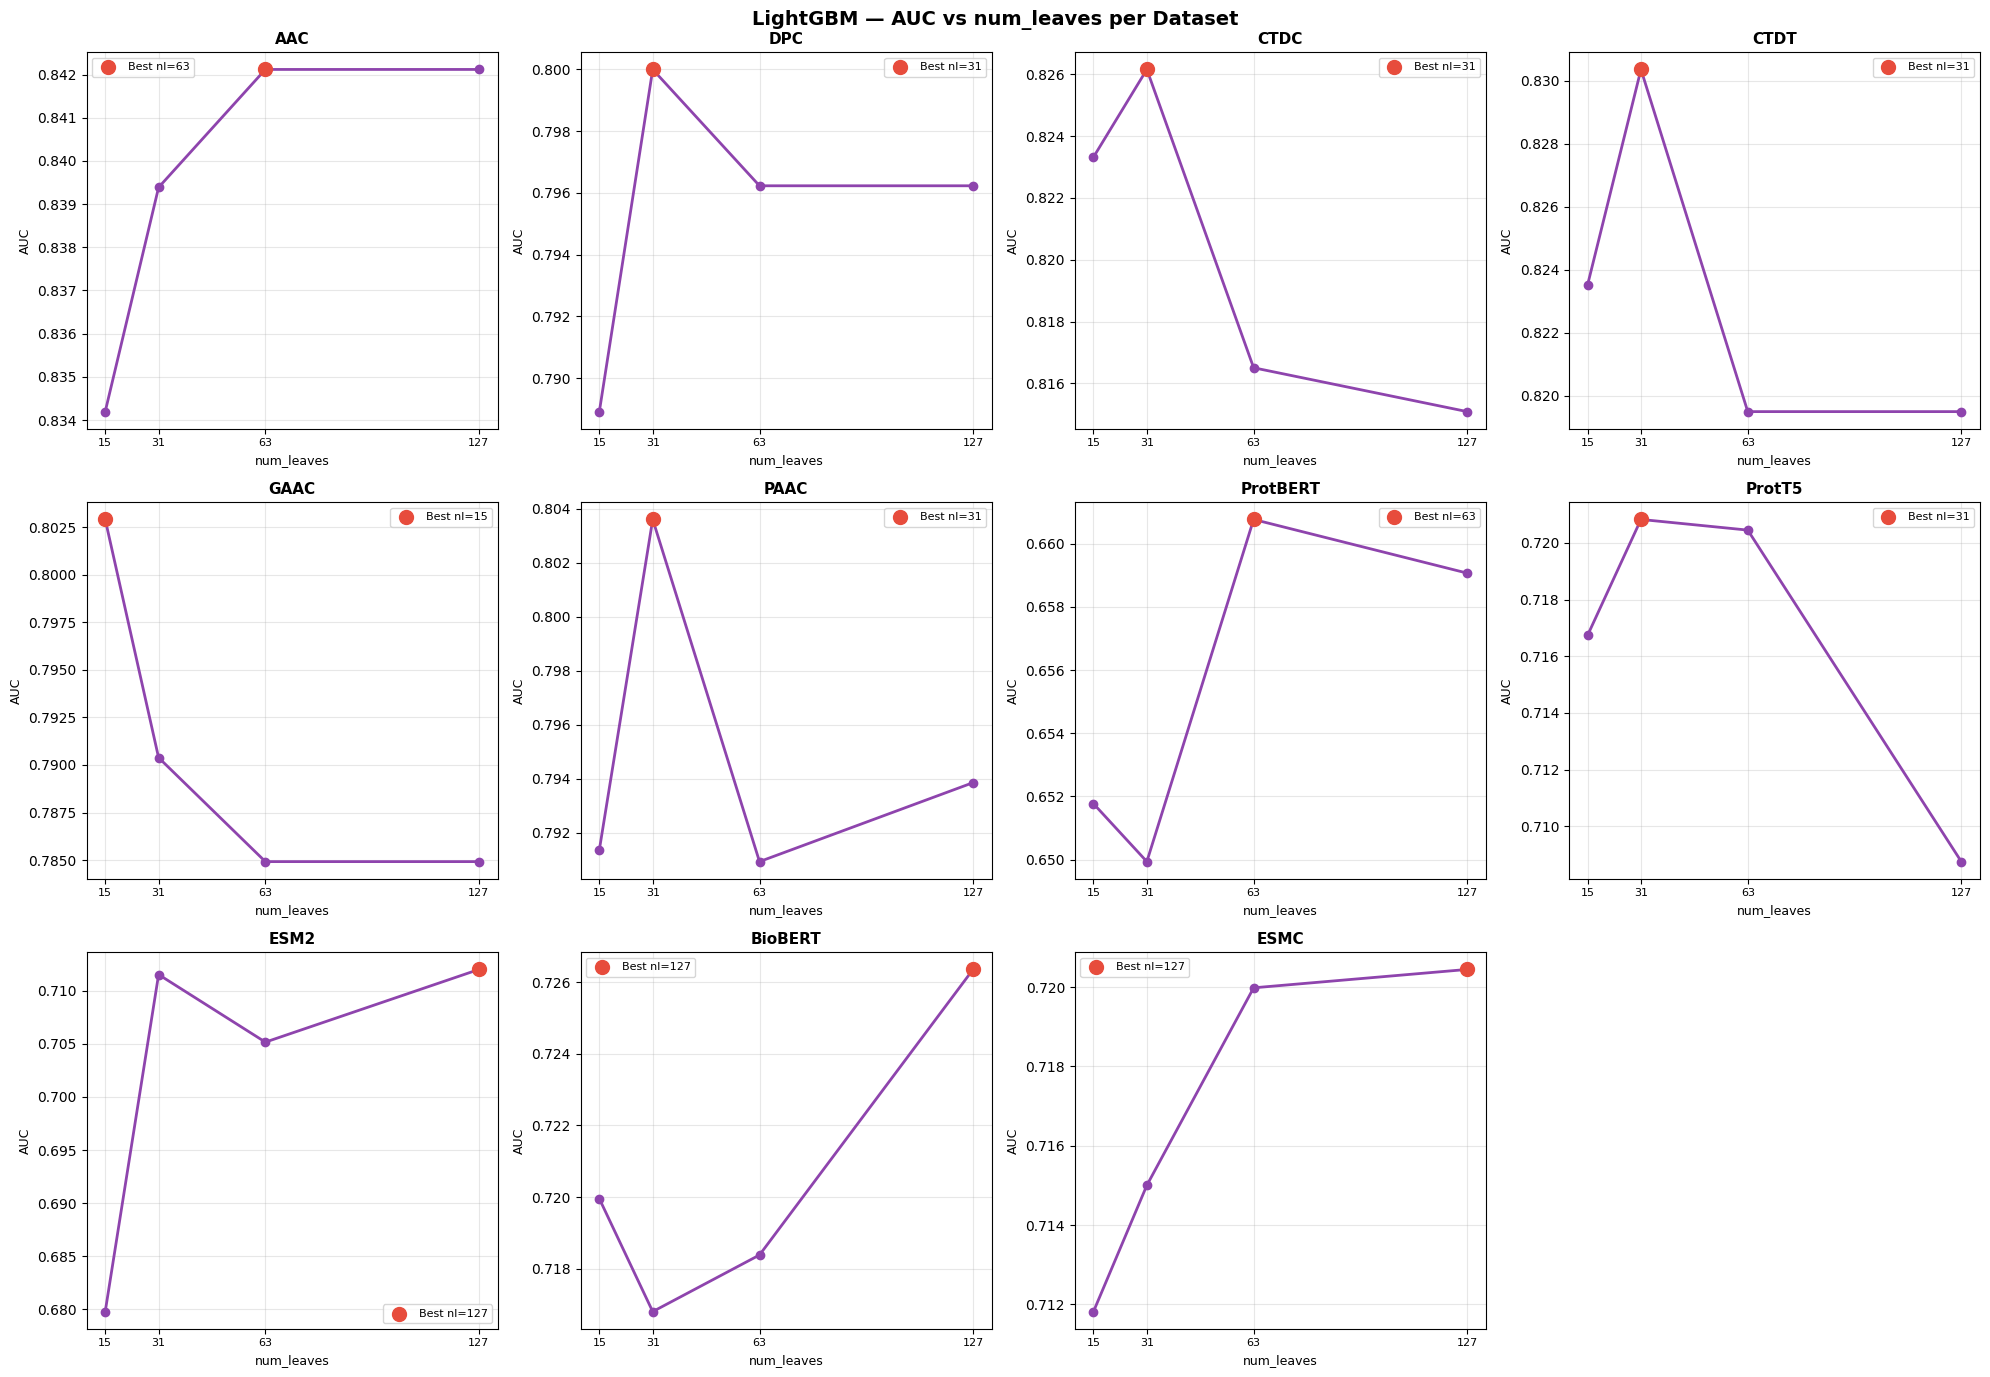

✅ num_leaves sensitivity plot saved
  LightGBM — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  num_leaves : 63

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7930
  Sensitivity : 0.7376
  Specificity : 0.8299
  F1 Score    : 0.7405
  MCC         : 0.5683
  AUC         : 0.8443
  Best iter   : 43
  TP=194  TN=327  FP=67  FN=69
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/lightgbm/AAC_LGBM_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  num_leaves : 31

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7367
  Sensitivity : 0.7

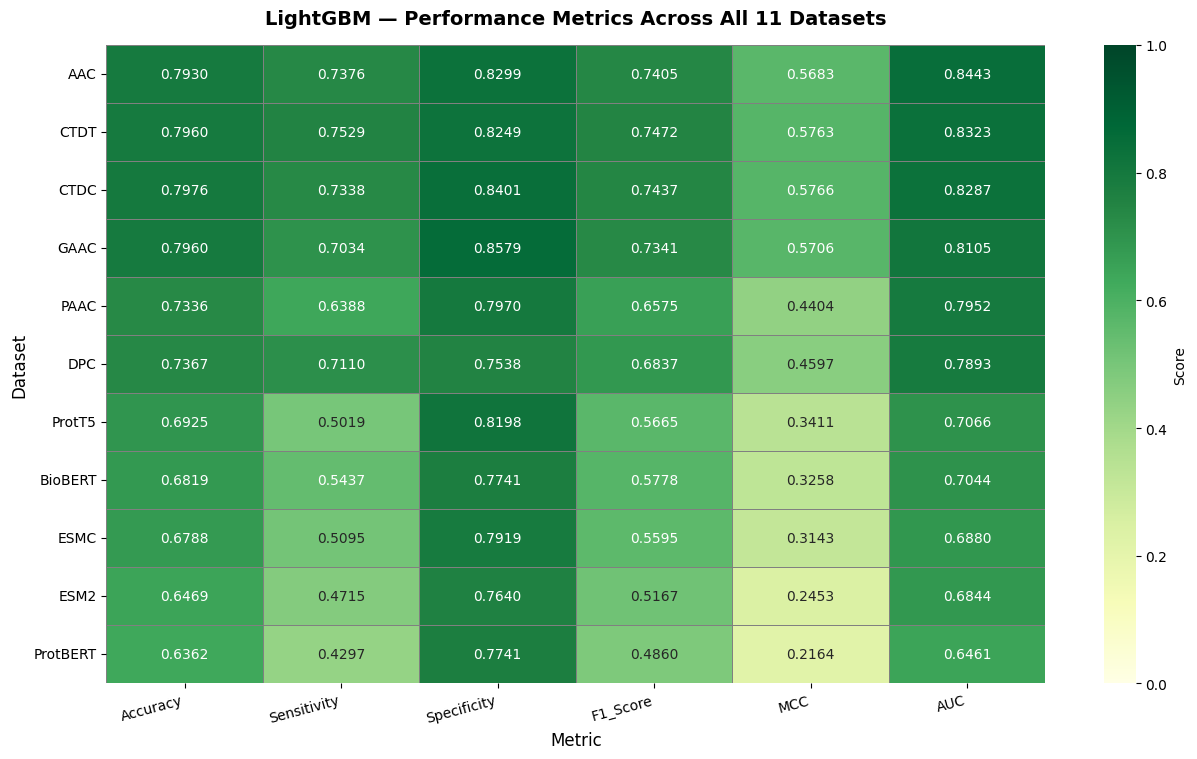

✅ Metrics heatmap saved


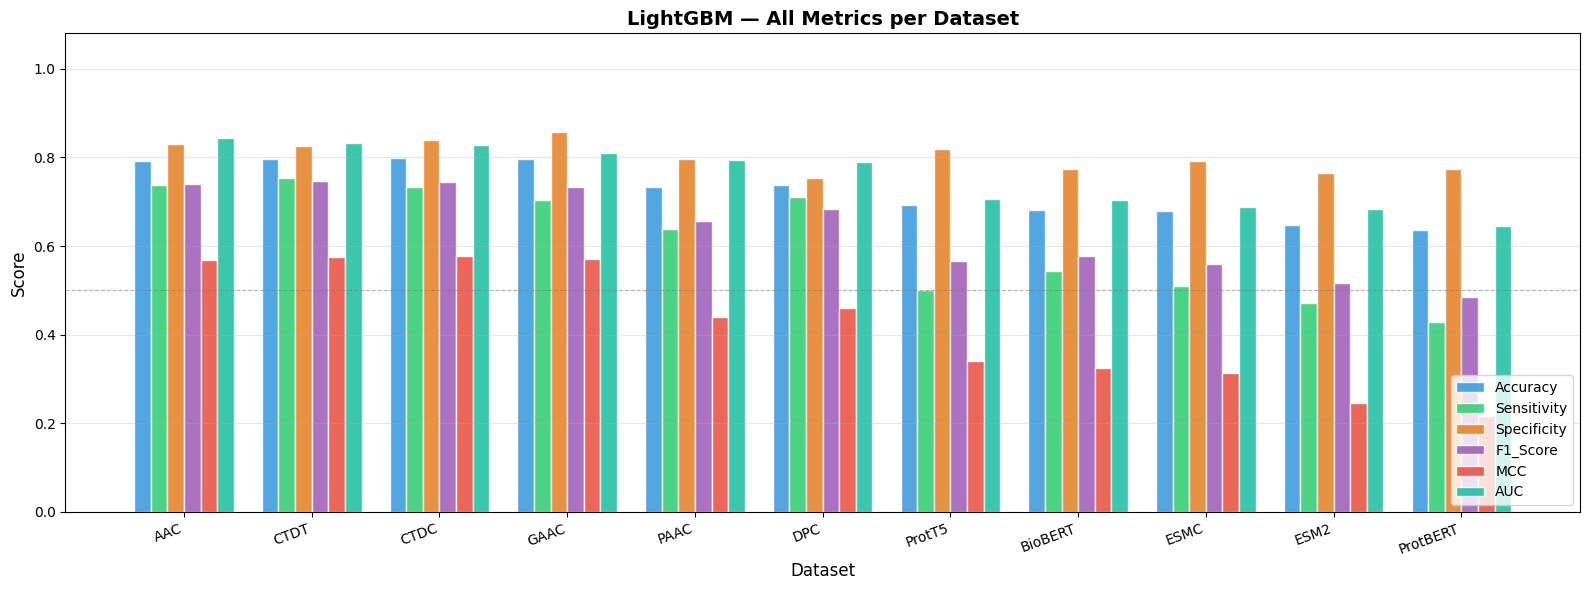

✅ Grouped bar chart saved


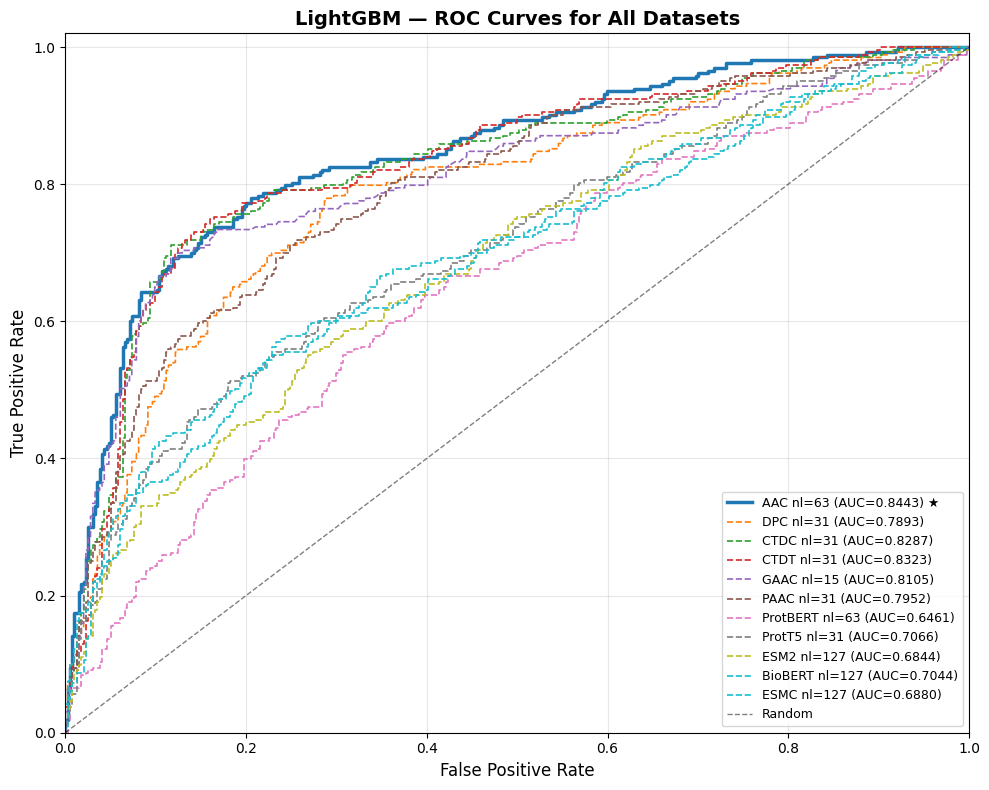

✅ ROC curves saved


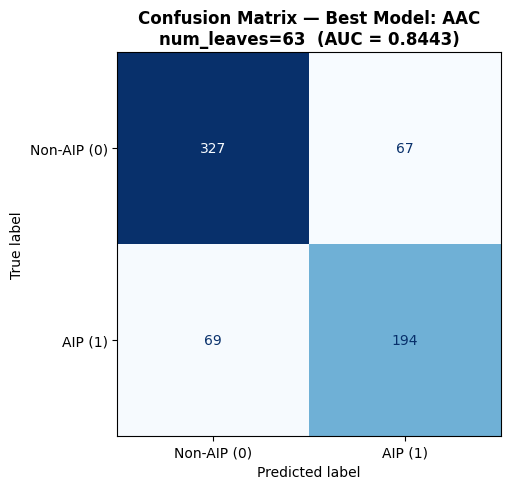

✅ Confusion matrix saved (AAC)


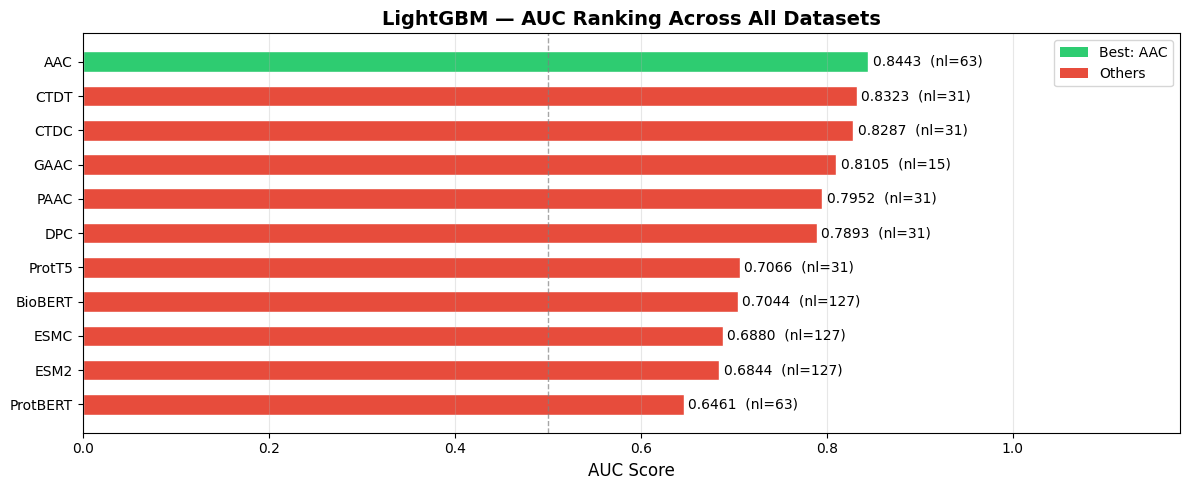

✅ AUC ranking chart saved


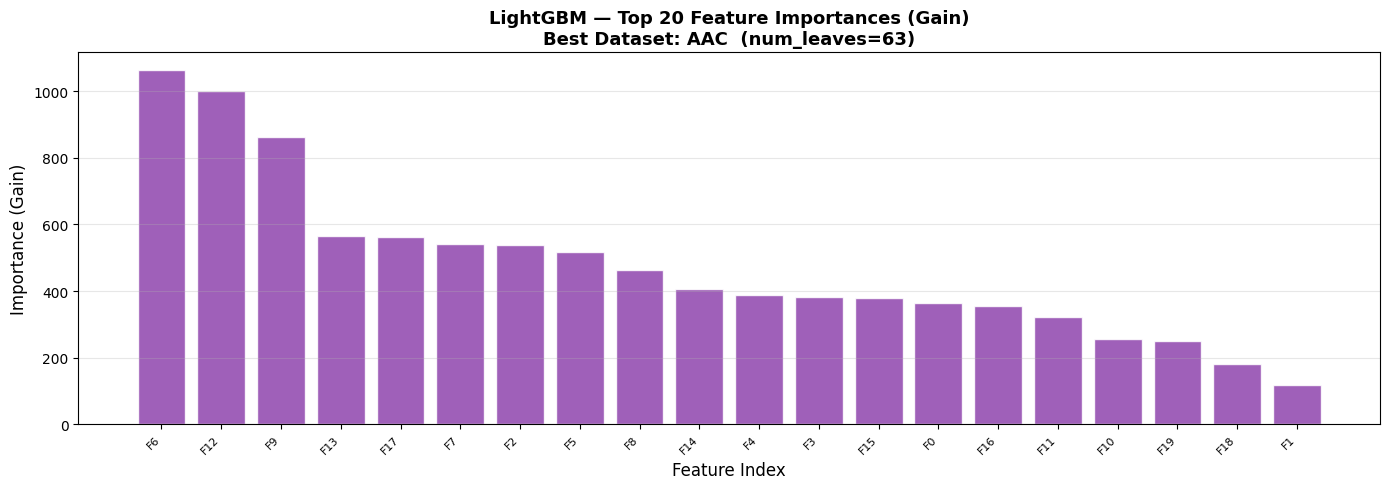

✅ Feature importance plot saved (AAC)


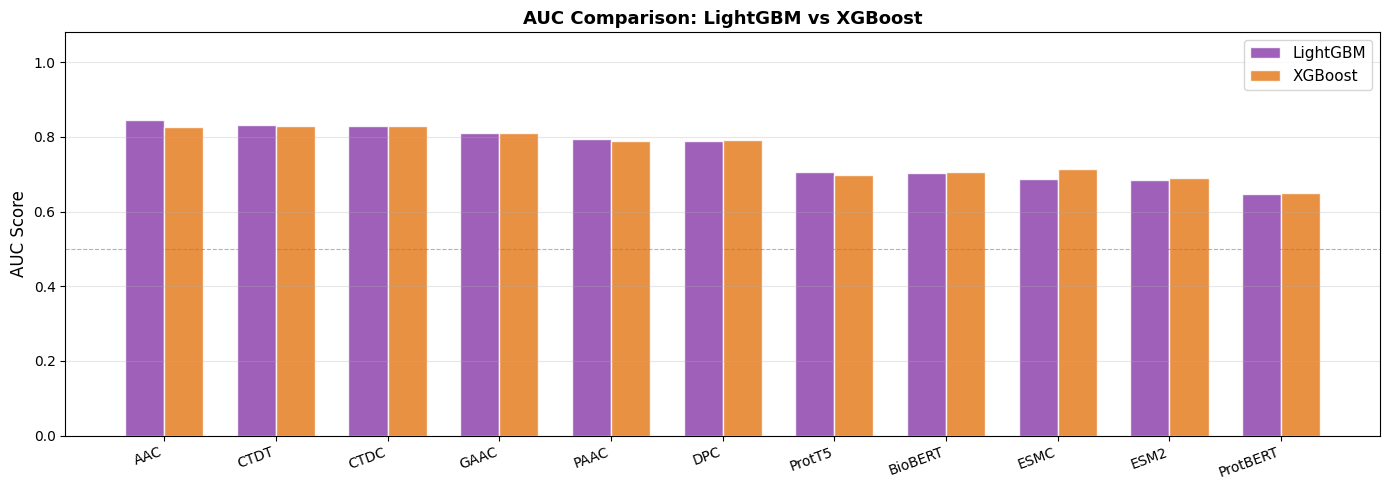

✅ LGBM vs XGBoost comparison plot saved
  LIGHTGBM — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/lightgbm
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/lightgbm
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/lightgbm

─────────────────────────────────────────────────────────────────
  Dataset         nl  iter      Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  AAC             63    43   0.7930   0.7376   0.8299   0.7405   0.5683   0.8443 ★
  CTDT            31    51   0.7960   0.7529   0.8249   0.7472   0.5763   0.8323
  CTDC            31    45   0.7976   0.7338   0.8401   0.7437   0.5766   0.8287
  GAAC            15    43   0.7960   0.7034   0.8579   0.7341   0.5706   0.8105
  PAAC            31    46   0.7336   0.6388   0.7970   0.6575   0.4404   0.7952
  DPC             31    3

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
!pip install lightgbm -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")
print(f"   LightGBM version : {lgb.__version__}")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/lightgbm"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/lightgbm"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/lightgbm"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── LightGBM hyperparameters ─────────────────────────────────
#
#  LightGBM vs XGBoost:
#    LightGBM uses Gradient-based One-Side Sampling (GOSS) and
#    Exclusive Feature Bundling (EFB) — much faster on large
#    feature sets (e.g. PLM 768–1280 dims), similar accuracy.
#
#  Key parameters:
#    n_estimators      : number of boosting rounds
#    max_depth         : -1 = no limit (leaf-wise growth controls depth)
#    num_leaves        : max leaves per tree
#                        key parameter in LightGBM — controls complexity
#                        higher = more complex, more overfit risk
#                        rule of thumb: num_leaves < 2^max_depth
#    learning_rate     : shrinkage per round
#    min_child_samples : min samples in a leaf — regularisation
#                        increase for small datasets (default 20)
#    subsample         : fraction of samples per tree (like RF)
#    colsample_bytree  : fraction of features per tree
#    reg_alpha         : L1 regularisation
#    reg_lambda        : L2 regularisation
#    scale_pos_weight  : handles class imbalance (neg/pos ratio)
#    verbose           : -1 = suppress all LightGBM logs
#    n_jobs            : -1 = all CPU cores
#
LGBM_PARAMS = {
    "n_estimators"    : 100,
    "max_depth"       : -1,
    "num_leaves"      : 31,
    "learning_rate"   : 0.1,
    "min_child_samples": 20,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha"       : 0.0,
    "reg_lambda"      : 0.0,
    "scale_pos_weight": 1.5,      # neg/pos ratio ≈ 1314/876
    "verbose"         : -1,
    "n_jobs"          : -1,
    "random_state"    : 42,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets         : {len(DATASETS)}")
print(f"   Train/Test       : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   n_estimators     : {LGBM_PARAMS['n_estimators']}")
print(f"   num_leaves       : {LGBM_PARAMS['num_leaves']}")
print(f"   learning_rate    : {LGBM_PARAMS['learning_rate']}")
print(f"   scale_pos_weight : {LGBM_PARAMS['scale_pos_weight']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — num_leaves Sensitivity Analysis
#            num_leaves is the most important LightGBM parameter.
#            Tests: 15, 31, 63, 127
#            (31 is default; 63–127 for complex datasets)
# ============================================================

print("=" * 65)
print("  LightGBM — num_leaves Sensitivity Analysis")
print("=" * 65)

LEAVES_VALUES      = [15, 31, 63, 127]
best_leaves_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    leaves_aucs = {}
    for nl in LEAVES_VALUES:
        lgbm = LGBMClassifier(
            n_estimators     = LGBM_PARAMS["n_estimators"],
            max_depth        = LGBM_PARAMS["max_depth"],
            num_leaves       = nl,
            learning_rate    = LGBM_PARAMS["learning_rate"],
            min_child_samples= LGBM_PARAMS["min_child_samples"],
            subsample        = LGBM_PARAMS["subsample"],
            colsample_bytree = LGBM_PARAMS["colsample_bytree"],
            scale_pos_weight = LGBM_PARAMS["scale_pos_weight"],
            verbose          = -1,
            n_jobs           = -1,
            random_state     = LGBM_PARAMS["random_state"],
        )
        lgbm.fit(X_train, y_train)
        y_prob_l          = lgbm.predict_proba(X_test)[:, 1]
        leaves_aucs[nl]   = round(roc_auc_score(y_test, y_prob_l), 4)

    best_nl                  = max(leaves_aucs, key=leaves_aucs.get)
    best_leaves_per_ds[ds_name] = best_nl

    l_str = "  ".join([f"nl={k}:{v:.3f}" for k, v in leaves_aucs.items()])
    print(f"\n  {ds_name:<10} → {l_str}")
    print(f"             Best num_leaves = {best_nl}  "
          f"(AUC={leaves_aucs[best_nl]:.4f})")

print(f"\n✅ num_leaves analysis complete")
print(f"   Best num_leaves per dataset: {best_leaves_per_ds}")


# ============================================================
#   CELL 6 — num_leaves Sensitivity Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    l_aucs = []
    for nl in LEAVES_VALUES:
        lgbm = LGBMClassifier(
            n_estimators=LGBM_PARAMS["n_estimators"],
            num_leaves=nl,
            learning_rate=LGBM_PARAMS["learning_rate"],
            min_child_samples=LGBM_PARAMS["min_child_samples"],
            subsample=LGBM_PARAMS["subsample"],
            colsample_bytree=LGBM_PARAMS["colsample_bytree"],
            scale_pos_weight=LGBM_PARAMS["scale_pos_weight"],
            verbose=-1, n_jobs=-1,
            random_state=LGBM_PARAMS["random_state"],
        )
        lgbm.fit(X_train, y_train)
        y_prob_l = lgbm.predict_proba(X_test)[:, 1]
        l_aucs.append(roc_auc_score(y_test, y_prob_l))

    best_nl  = best_leaves_per_ds.get(ds_name, 31)
    best_idx = LEAVES_VALUES.index(best_nl)

    ax.plot(LEAVES_VALUES, l_aucs, "o-",
            color="#8e44ad", linewidth=2, markersize=6)
    ax.scatter([best_nl], [l_aucs[best_idx]],
               color="#e74c3c", s=100, zorder=5,
               label=f"Best nl={best_nl}")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("num_leaves", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_xticks(LEAVES_VALUES)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("LightGBM — AUC vs num_leaves per Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LGBM_num_leaves_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ num_leaves sensitivity plot saved")


# ============================================================
#   CELL 7 — Main Training Loop (using best num_leaves per dataset)
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  LightGBM — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Use best num_leaves from sensitivity analysis ─────────
    nl_used = best_leaves_per_ds.get(ds_name, LGBM_PARAMS["num_leaves"])
    print(f"  num_leaves : {nl_used}")

    # ── Train LightGBM ───────────────────────────────────────
    clf = LGBMClassifier(
        n_estimators     = LGBM_PARAMS["n_estimators"],
        max_depth        = LGBM_PARAMS["max_depth"],
        num_leaves       = nl_used,
        learning_rate    = LGBM_PARAMS["learning_rate"],
        min_child_samples= LGBM_PARAMS["min_child_samples"],
        subsample        = LGBM_PARAMS["subsample"],
        colsample_bytree = LGBM_PARAMS["colsample_bytree"],
        reg_alpha        = LGBM_PARAMS["reg_alpha"],
        reg_lambda       = LGBM_PARAMS["reg_lambda"],
        scale_pos_weight = LGBM_PARAMS["scale_pos_weight"],
        verbose          = LGBM_PARAMS["verbose"],
        n_jobs           = LGBM_PARAMS["n_jobs"],
        random_state     = LGBM_PARAMS["random_state"],
    )
    clf.fit(
        X_train, y_train,
        eval_set         = [(X_test, y_test)],
        callbacks        = [lgb.early_stopping(stopping_rounds=20,
                                               verbose=False),
                            lgb.log_evaluation(period=-1)]
    )

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]     = ds_name
    metrics["Features"]    = X.shape[1]
    metrics["Leaves_used"] = nl_used
    metrics["Best_iter"]   = clf.best_iteration_ if clf.best_iteration_ else LGBM_PARAMS["n_estimators"]
    metrics["Train_N"]     = len(X_train)
    metrics["Test_N"]      = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  Best iter   : {metrics['Best_iter']}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_LGBM_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test"  : y_test,
        "y_pred"  : y_pred,
        "y_prob"  : y_prob,
        "clf"     : clf,
        "scaler"  : scaler,
        "nl"      : nl_used,
        "best_iter": metrics["Best_iter"],
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 8 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Leaves_used", "Best_iter", "Accuracy",
               "Sensitivity", "Specificity", "F1_Score",
               "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── LightGBM Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "LGBM_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 9 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR,
                                f"LGBM_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR,
                                f"LGBM_best_scaler_{best_name}.joblib")
lgbm_txt_path    = os.path.join(MODELS_DIR,
                                f"LGBM_best_model_{best_name}.txt")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

# Also save in native LightGBM text format for portability
best_model.booster_.save_model(lgbm_txt_path)

print(f"✅ Best model saved")
print(f"   Dataset      : {best_name}")
print(f"   num_leaves   : {best_leaves_per_ds.get(best_name)}")
print(f"   AUC          : {best_auc:.4f}")
print(f"   Model (.joblib) : {best_model_path}")
print(f"   Model (.txt)    : {lgbm_txt_path}")
print(f"   Scaler          : {best_scaler_path}")


# ============================================================
#   CELL 10 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity",
             "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("LightGBM — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15,
                   ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LGBM_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 11 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("LightGBM — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"],
                   rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LGBM_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 12 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} nl={data['nl']} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("LightGBM — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LGBM_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 13 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"num_leaves={best_leaves_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"LGBM_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 14 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, nl in zip(bars, sorted_df["AUC"],
                         sorted_df["Leaves_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  (nl={nl})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("LightGBM — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LGBM_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 15 — Visualization 6: Feature Importance (Best Model)
#             LightGBM provides 3 importance types:
#               "split" — number of times a feature is used
#               "gain"  — total gain from splits using the feature ✅
# ============================================================

importances = best_model.booster_.feature_importance(importance_type="gain")
n_top       = min(30, len(importances))
top_idx     = np.argsort(importances)[::-1][:n_top]
top_imp     = importances[top_idx]
top_labels  = [f"F{i}" for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_top), top_imp, color="#8e44ad",
       edgecolor="white", alpha=0.85)
ax.set_xticks(range(n_top))
ax.set_xticklabels(top_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Importance (Gain)", fontsize=12)
ax.set_title(f"LightGBM — Top {n_top} Feature Importances (Gain)\n"
             f"Best Dataset: {best_name}  "
             f"(num_leaves={best_leaves_per_ds.get(best_name)})",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"LGBM_feature_importance_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Feature importance plot saved ({best_name})")


# ============================================================
#   CELL 16 — LGBM vs XGBoost Comparison (if XGB results exist)
# ============================================================

xgb_summary_path = (
    "/content/drive/MyDrive/Colab Notebooks/AIP Prediction"
    "/results/xgboost/XGB_all_results_summary.csv"
)

if os.path.exists(xgb_summary_path):
    df_xgb    = pd.read_csv(xgb_summary_path).set_index("Dataset")
    common_ds = [d for d in df_results["Dataset"] if d in df_xgb.index]

    lgbm_aucs = df_results.set_index("Dataset").loc[common_ds, "AUC"]
    xgb_aucs  = df_xgb.loc[common_ds, "AUC"]

    x     = np.arange(len(common_ds))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, lgbm_aucs.values, width,
           label="LightGBM", color="#8e44ad",
           alpha=0.85, edgecolor="white")
    ax.bar(x + width/2, xgb_aucs.values, width,
           label="XGBoost", color="#e67e22",
           alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(common_ds, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("AUC Score", fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.set_title("AUC Comparison: LightGBM vs XGBoost",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.5, color="grey", linestyle="--",
               linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,
                             "LGBM_vs_XGB_AUC_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ LGBM vs XGBoost comparison plot saved")
else:
    print("ℹ️  XGBoost results not found — skipping LGBM vs XGB comparison")
    print("   Run XGB_classifier_all_datasets.py first to enable this plot")


# ============================================================
#   CELL 17 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  LIGHTGBM — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'nl':>5} {'iter':>5} {'Acc':>8} {'Sn':>8} "
      f"{'Sp':>8} {'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {int(row['Leaves_used']):>5} "
          f"{int(row['Best_iter']):>5} "
          f"{row['Accuracy']:>8.4f} {row['Sensitivity']:>8.4f} "
          f"{row['Specificity']:>8.4f} {row['F1_Score']:>8.4f} "
          f"{row['MCC']:>8.4f} {row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset  : {best_name}")
print(f"     num_leaves    : {best_leaves_per_ds.get(best_name)}")
print(f"     Best iter     : {best_row['Best_iter']}")
print(f"     Accuracy      : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity   : {best_row['Sensitivity']:.4f}")
print(f"     Specificity   : {best_row['Specificity']:.4f}")
print(f"     F1 Score      : {best_row['F1_Score']:.4f}")
print(f"     MCC           : {best_row['MCC']:.4f}")
print(f"     AUC           : {best_row['AUC']:.4f}")
print(f"\n  LightGBM advantages:")
print(f"     ✅ Leaf-wise tree growth → more accurate than level-wise")
print(f"     ✅ GOSS + EFB → faster than XGBoost on high-dim PLM data")
print(f"     ✅ Early stopping prevents overfitting automatically")
print(f"     ✅ Best num_leaves selected per dataset automatically")
print(f"     ✅ Native .txt model format for portability")
print(f"     ✅ LGBM vs XGBoost comparison auto-generated if XGB run first")
print("=" * 65)